In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

funds = pd.read_csv(
    "../data/processed/fund_master_clean.csv"
)

holdings = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [21]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

risk_report = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    risk_report.append([
        code,
        var95,
        cvar95
    ])

risk_df = pd.DataFrame(
    risk_report,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [22]:
risk_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [23]:
rolling_data = nav.copy()

rolling_data['rolling_sharpe'] = (
    rolling_data
    .groupby('amfi_code')['daily_return']
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        )
        * np.sqrt(252)
    )
)

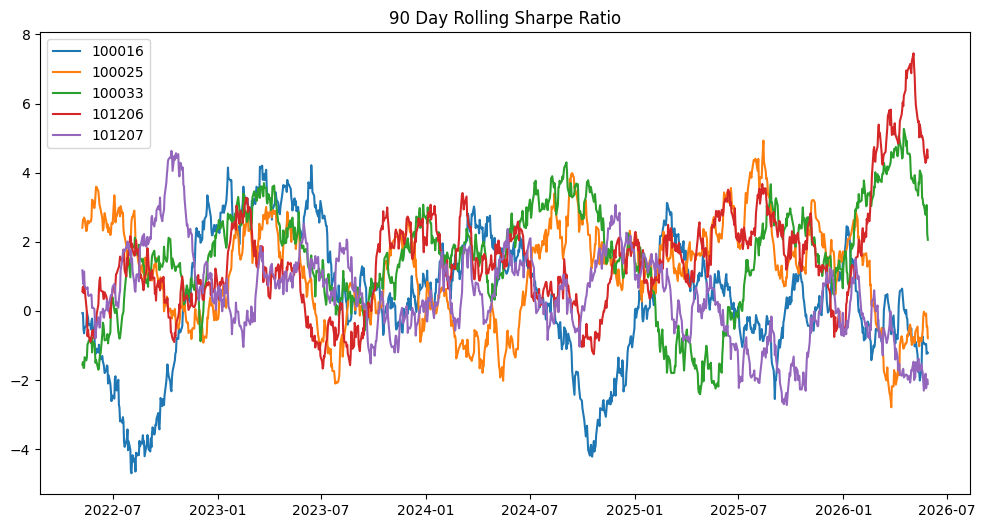

In [24]:
top5 = (
    rolling_data['amfi_code']
    .dropna()
    .unique()[:5]
)

plt.figure(figsize=(12,6))

for code in top5:

    temp = rolling_data[
        rolling_data['amfi_code']==code
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(code)
    )

plt.legend()
plt.title(
    "90 Day Rolling Sharpe Ratio"
)

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [25]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions['year'] = (
    transactions['transaction_date']
    .dt.year
)

first_year = (
    transactions
    .groupby('investor_id')['year']
    .min()
)

transactions['cohort_year'] = (
    transactions['investor_id']
    .map(first_year)
)

In [26]:
print(transactions.columns.tolist())
print(transactions.head())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'year', 'cohort_year']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       REDEMPTION      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          LUMPSUM        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30 

In [27]:
cohort = (
    transactions
    .groupby('cohort_year')
    .agg(
        investors=('investor_id', 'nunique'),
        transactions=('investor_id', 'count'),
        avg_investment=('amount_inr', 'mean'),
        total_investment=('amount_inr', 'sum')
    )
    .reset_index()
)

cohort

,cohort_year,investors,transactions,avg_investment,total_investment
0,2024,4803,32499,107422.541832,3491125187
1,2025,197,279,109158.577061,30455243


In [28]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'year', 'cohort_year']


In [29]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,year,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,2024


In [30]:
print(funds.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [31]:
transactions = transactions.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

In [32]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'year', 'cohort_year', 'scheme_name']


In [33]:
top_fund = (
    transactions
    .groupby(['cohort_year', 'scheme_name'])['amount_inr']
    .sum()
    .reset_index()
)

top_fund = (
    top_fund
    .sort_values(
        ['cohort_year', 'amount_inr'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .first()
    .reset_index()
)

top_fund

,cohort_year,scheme_name,amount_inr
0,2024,UTI Nifty 50 Index Fund - Regular - Growth,100126141
1,2025,SBI Small Cap Fund - Direct Plan - Growth,1478507


In [34]:
# Ensure date column is datetime
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

# Keep only SIP transactions
sip = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

# Sort by investor and date
sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

# Calculate days between SIPs
sip['gap_days'] = (
    sip.groupby('investor_id')['transaction_date']
       .diff()
       .dt.days
)

# Investor summary
sip_summary = (
    sip.groupby('investor_id')
       .agg(
           sip_count=('transaction_date', 'count'),
           avg_gap=('gap_days', 'mean')
       )
       .reset_index()
)

# Keep investors with at least 6 SIPs
sip_summary = sip_summary[
    sip_summary['sip_count'] >= 6
]

# Risk classification
sip_summary['status'] = np.where(
    sip_summary['avg_gap'] > 35,
    'At Risk',
    'Healthy'
)

# Display results
sip_summary.head()

,investor_id,sip_count,avg_gap,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [35]:
print("Total SIP Investors:", len(sip_summary))

print("\nStatus Distribution:")
print(sip_summary['status'].value_counts())

Total SIP Investors: 1362

Status Distribution:
status
At Risk    1332
Healthy      30
Name: count, dtype: int64


In [36]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [37]:
# Create squared weights
holdings['weight_sq'] = holdings['weight_pct'] ** 2

# Calculate HHI
hhi = (
    holdings
    .groupby('amfi_code')['weight_sq']
    .sum()
    .reset_index()
)

# Add scheme names
hhi = hhi.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Sort by concentration
hhi = hhi.sort_values(
    'weight_sq',
    ascending=False
)

# Rename column
hhi = hhi.rename(
    columns={'weight_sq': 'HHI'}
)

hhi.head(10)

,amfi_code,HHI,scheme_name
11,119092,2064.4767,Axis Bluechip Fund - Regular - Growth
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth
18,119599,1747.5096,SBI Small Cap Fund - Direct Plan - Growth
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,1682.9820,Nippon India Large Cap Fund - Regular - Growth
29,148568,1679.2973,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,1575.7036,ICICI Pru Midcap Fund - Regular - Growth
22,120506,1537.9360,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,1524.1398,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,1496.8035,Kotak Bluechip Fund - Regular - Growth


In [38]:
hhi['concentration_level'] = np.where(
    hhi['HHI'] > 2000,
    'Highly Concentrated',
    'Diversified'
)

hhi.head(10)

,amfi_code,HHI,scheme_name,concentration_level
11,119092,2064.4767,Axis Bluechip Fund - Regular - Growth,Highly Concentrated
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Highly Concentrated
18,119599,1747.5096,SBI Small Cap Fund - Direct Plan - Growth,Diversified
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,Diversified
7,118632,1682.9820,Nippon India Large Cap Fund - Regular - Growth,Diversified
29,148568,1679.2973,Mirae Asset Emerging Bluechip Fund - Regular -...,Diversified
21,120505,1575.7036,ICICI Pru Midcap Fund - Regular - Growth,Diversified
22,120506,1537.9360,ICICI Pru Value Discovery Fund - Regular - Growth,Diversified
27,125498,1524.1398,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Diversified
23,120841,1496.8035,Kotak Bluechip Fund - Regular - Growth,Diversified


Funds with higher HHI values exhibit concentrated sector exposure, increasing portfolio-specific risk. Funds with lower HHI values are better diversified across sectors and may offer more stable risk-adjusted returns.


In [39]:
hhi.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

# Advanced Insights

### 1. Risk Analysis
Small-cap funds exhibited the most negative VaR95 values, indicating higher downside volatility compared to diversified equity funds.

### 2. Tail Risk
CVaR analysis showed that certain high-growth schemes experience substantially larger losses during extreme market conditions.

### 3. Rolling Sharpe Trends
Several funds maintained stable positive rolling Sharpe ratios, demonstrating consistent risk-adjusted performance over time.

### 4. Investor Cohorts
The 2024 investor cohort contributed the highest total investments, with strong participation in index and small-cap funds.

### 5. SIP Continuity
Most investors maintained regular SIP contributions. Investors with average SIP gaps greater than 35 days were classified as at-risk.